# Autostep Variant B on one contaminated network — minimal numpy version

The single result from `experiment_1_stationary.ipynb` (1a, Variant B, no L1), rewritten in plain
numpy for one seed: no jax, no vmap, no scan, no caching, no imports from the project. Read it top
to bottom — teacher, connectivity, network, Autostep update, loop, plot.

**The question.** Every cross-task connection in this network is useless by construction, so
Autostep should hold their step-sizes near their 1e-6 starting value while the useful connections'
step-sizes climb.

**Variant B** is the `squared_inputs` version of Autostep: each layer is treated as its own linear
problem, so the curvature basis of a weight is the squared value of the *source unit* it reads
(the network input for layer 1, the hidden activation for layer 2). That is the only place a
network-specific choice enters — everything else is Autostep exactly as derived for the linear case.

Numbers here are one seed with numpy's RNG, so they will not match the 30-seed jax run
bit-for-bit; the construction, the hyperparameters and the qualitative result are the same.

In [21]:
import matplotlib.pyplot as plt
import numpy as np

SEED = 0

# --- Problem: stationary 2-task multi-GEOFF ---
N_TASKS = 2
N_FEATURES_PER_TASK = 2          # -> 4 inputs, laid out task-major: [t0, t0, t1, t1]
N_OUTPUTS_PER_TASK = 1           # -> 2 outputs, one per task
TEACHER_HIDDEN = 10              # LTUs per task inside the teacher
NOISE_STD = 1.0                  # per-output observation noise, so the best MSE is 1.0

# --- Learner ---
N_HIDDEN = 4                     # 2 hidden units per task
LEAKY_SLOPE = 0.01               # jax.nn.leaky_relu's default
INIT_ALPHA = 1e-6                # every connection's starting step-size
META_LR = 0.02                   # Autostep's meta step-size
TAU = 1e4                        # Autostep's normalizer decay constant

# --- Training ---
N_STEPS = 300_000              # one sample per step, online
SNAPSHOT_EVERY = 4_000           # -> 250 recorded points

N_FEATURES = N_TASKS * N_FEATURES_PER_TASK
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
rng = np.random.default_rng(SEED)

## The teacher

Two independent GEOFF sub-networks, one per task. Task `t` reads only its own two inputs, passes
them through `TEACHER_HIDDEN` linear threshold units, and reads out a single output as a signed sum
of them. Nothing connects one task to the other, which is what makes every cross-task connection in
the learner useless.

In [22]:
# Binary input weights, zero thresholds; output weights are +-2/sqrt(m) so each output's
# noise-free signal has unit variance, putting the irreducible per-output MSE at NOISE_STD^2.
teacher_in = rng.integers(0, 2, (N_TASKS, TEACHER_HIDDEN, N_FEATURES_PER_TASK)).astype(np.float64)
teacher_out = (rng.integers(0, 2, (N_TASKS, N_OUTPUTS_PER_TASK, TEACHER_HIDDEN)) * 2 - 1) \
    * (2.0 / np.sqrt(TEACHER_HIDDEN))


def sample():
    """One (x, y) pair: uniform inputs, noisy targets."""
    x = rng.uniform(-1.0, 1.0, N_FEATURES)
    hidden = (np.einsum('tmn,tn->tm', teacher_in, x.reshape(N_TASKS, N_FEATURES_PER_TASK)) > 0)
    y = np.einsum('tpm,tm->tp', teacher_out, hidden.astype(np.float64)).reshape(N_OUTPUTS)
    return x, y + NOISE_STD * rng.standard_normal(N_OUTPUTS)


IRREDUCIBLE_MSE = NOISE_STD ** 2
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0        # what predicting the mean gets you
print('one sample:', sample())

one sample: (array([ 0.37689346, -0.22215715, -0.72980699,  0.44297668]), array([0.84711465, 0.35537271]))


## Connectivity

The learner is a two-layer MLP whose connections are a fixed 0/1 mask. The mask is the good
block-sparse structure — hidden unit `j` wired only to its own task's inputs and outputs —
*contaminated* the way 1a does it: hidden units 0 and 2 additionally feed the other task's output,
hidden units 1 and 3 additionally read the other task's inputs. Every connection added that way
crosses tasks, and a cross-task connection is useless here: a unit that only reads task 0's inputs
carries nothing about task 1, and noise injected from task 1's inputs cannot help task 0's output.

Each layer gets one extra column for a constant-1 input, so the biases are ordinary weights inside
the weight matrix. Autostep normalizes a row of step-sizes by a sum over that matrix's columns, so a
bias has to live in the matrix to be part of that sum. Biases belong to no task and are excluded
from the useful/useless comparison below.

In [23]:
hidden_task = np.repeat(np.arange(N_TASKS), N_HIDDEN // N_TASKS)          # [0, 0, 1, 1]
input_task = np.repeat(np.arange(N_TASKS), N_FEATURES_PER_TASK)           # [0, 0, 1, 1]
output_task = np.repeat(np.arange(N_TASKS), N_OUTPUTS_PER_TASK)           # [0, 1]

# Which (row, col) pairs join two different tasks, per layer.
cross1 = hidden_task[:, None] != input_task[None, :]                      # hidden <- inputs
cross2 = output_task[:, None] != hidden_task[None, :]                     # outputs <- hidden

# The contamination: even hidden units gain outgoing cross-task connections, odd ones incoming.
extra_in = cross1 & (np.arange(N_HIDDEN)[:, None] % 2 == 1)
extra_out = cross2 & (np.arange(N_HIDDEN)[None, :] % 2 == 0)

# Masks, with a trailing all-ones bias column. mask1 is (hidden, inputs + 1), mask2 (outputs, hidden + 1).
mask1 = np.c_[~cross1 | extra_in, np.ones(N_HIDDEN, bool)].astype(np.float64)
mask2 = np.c_[~cross2 | extra_out, np.ones(N_OUTPUTS, bool)].astype(np.float64)

USEFUL, USELESS, BIAS, NONE = 0, 1, 2, -1


def label_connections(mask, cross):
    """What each position of a weight matrix is, for the statistics further down."""
    labels = np.full(mask.shape, NONE)
    labels[:, :-1] = np.where(cross, USELESS, USEFUL)      # a cross-task connection is useless
    labels[:, -1] = BIAS                                   # the constant-1 column belongs to no task
    labels[mask == 0] = NONE                               # ... and nothing exists where the mask is 0
    return labels


labels1, labels2 = label_connections(mask1, cross1), label_connections(mask2, cross2)

print('mask1 (hidden x [inputs, bias])\n', mask1)
print('mask2 (outputs x [hidden, bias])\n', mask2)
print('labels1 (-1 none, 0 useful, 1 useless, 2 bias)\n', labels1)
print('labels2\n', labels2)

mask1 (hidden x [inputs, bias])
 [[1. 1. 0. 0. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
mask2 (outputs x [hidden, bias])
 [[1. 1. 1. 0. 1.]
 [1. 0. 1. 1. 1.]]
labels1 (-1 none, 0 useful, 1 useless, 2 bias)
 [[ 0  0 -1 -1  2]
 [ 0  0  1  1  2]
 [-1 -1  0  0  2]
 [ 1  1  0  0  2]]
labels2
 [[ 0  0  1 -1  2]
 [ 1 -1  0  0  2]]


## The network and Autostep's state

`w1`, `w2` are LeCun-uniform, with the bias column at 0 and masked-out positions held at exactly 0.
Autostep carries three per-weight quantities: the step-size `alpha`, the gradient trace `h`, and the
normalizer `v`. Every connection starts at the same tiny step-size, so any separation later is
something Autostep produced.

In [24]:
def init_weights(mask):
    """LeCun uniform, zero biases, masked positions exactly zero."""
    bound = np.sqrt(3.0 / mask.shape[1])
    w = rng.uniform(-bound, bound, mask.shape)
    w[:, -1] = 0.0                          # the bias column
    return w * mask


w1, w2 = init_weights(mask1), init_weights(mask2)
alpha1, alpha2 = np.full_like(w1, INIT_ALPHA), np.full_like(w2, INIT_ALPHA)
h1, h2 = np.zeros_like(w1), np.zeros_like(w2)
v1, v2 = np.zeros_like(w1), np.zeros_like(w2)

## The Autostep update

In [25]:
def autostep(w, alpha, h, v, g, source):
    """One Autostep update of a single layer. `source` is the layer's input vector.

    Every array may carry extra leading axes (the sweep at the bottom puts one run per leading
    index), which is all `...` and `axis=-1` are doing here.
    """
    d = (source ** 2)[..., None, :]                     # same curvature term for every row
    hg = h * g
    v = np.maximum(np.abs(hg), v + alpha * d * (np.abs(hg) - v) / TAU)

    # exp(0) = 1 leaves alpha untouched where v is still 0, i.e. where nothing has happened yet.
    alpha = alpha * np.exp(META_LR * np.divide(hg, v, out=np.zeros_like(hg), where=v > 0))
    alpha = alpha / np.maximum(1.0, (alpha * d).sum(axis=-1, keepdims=True))

    h = h * np.maximum(0.0, 1.0 - alpha * d) + alpha * g
    return w - alpha * g, alpha, h, v

## Training

One sample per step, one gradient step per sample, gradients written out by hand. The forward pass
appends a constant 1 to each layer's input so the bias column has something to read.

In [26]:
snap_steps, snap_alpha1, snap_alpha2, snap_w1, snap_w2 = [], [], [], [], []
mse_sum, mse_curve = 0.0, []

for step in range(1, N_STEPS + 1):
    x, y = sample()

    # Forward. `xb` and `hb` are the two layers' inputs, and Variant B's curvature terms.
    xb = np.append(x, 1.0)
    pre = (w1 * mask1) @ xb
    hid = np.where(pre > 0, pre, LEAKY_SLOPE * pre)                      # leaky relu
    hb = np.append(hid, 1.0)
    out = (w2 * mask2) @ hb

    # Backward, for loss = sum_i (out_i - y_i)^2.
    d_out = 2.0 * (out - y)
    g2 = np.outer(d_out, hb) * mask2
    d_hid = ((w2 * mask2).T @ d_out)[:N_HIDDEN]
    g1 = np.outer(d_hid * np.where(pre > 0, 1.0, LEAKY_SLOPE), xb) * mask1

    w1, alpha1, h1, v1 = autostep(w1, alpha1, h1, v1, g1, xb)
    w2, alpha2, h2, v2 = autostep(w2, alpha2, h2, v2, g2, hb)

    mse_sum += np.mean((out - y) ** 2)
    if step % SNAPSHOT_EVERY == 0:
        snap_steps.append(step)
        snap_alpha1.append(alpha1.copy())
        snap_alpha2.append(alpha2.copy())
        snap_w1.append(w1.copy())                    # signed, so the sign flips stay visible
        snap_w2.append(w2.copy())
        mse_curve.append(mse_sum / SNAPSHOT_EVERY)
        mse_sum = 0.0

snap_steps = np.array(snap_steps)
snap_alpha1, snap_alpha2 = np.array(snap_alpha1), np.array(snap_alpha2)
snap_w1, snap_w2 = np.array(snap_w1), np.array(snap_w2)
print(f'per-output MSE: {mse_curve[0]:.3f} at the start, {np.mean(mse_curve[-5:]):.3f} at the end '
      f'(mean predictor {BASELINE_MSE:.1f}, irreducible {IRREDUCIBLE_MSE:.1f})')

per-output MSE: 1.306 at the start, 1.101 at the end (mean predictor 2.0, irreducible 1.0)


## The result

Four figures, one line per connection: step-size and weight for the input layer, then the same two
for the output layer. Blue is a useful (same-task) connection, red a useless (cross-task) one, green
a bias. Weights are signed, so a connection driven to zero is one that meets the dashed line rather
than one that merely gets small.

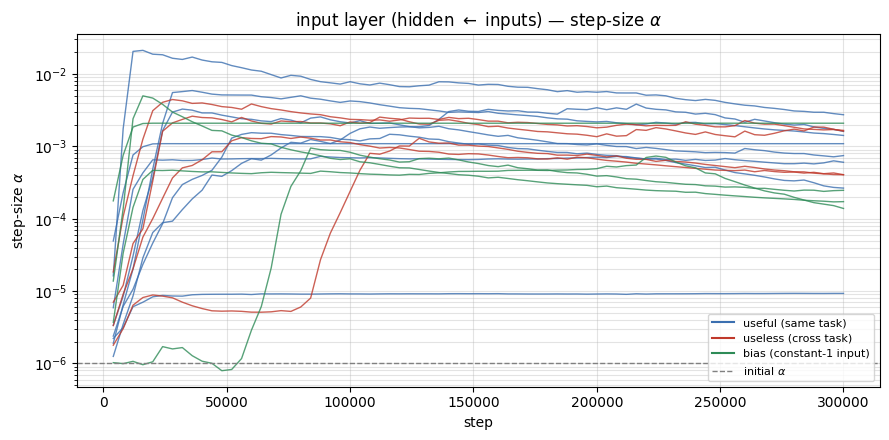

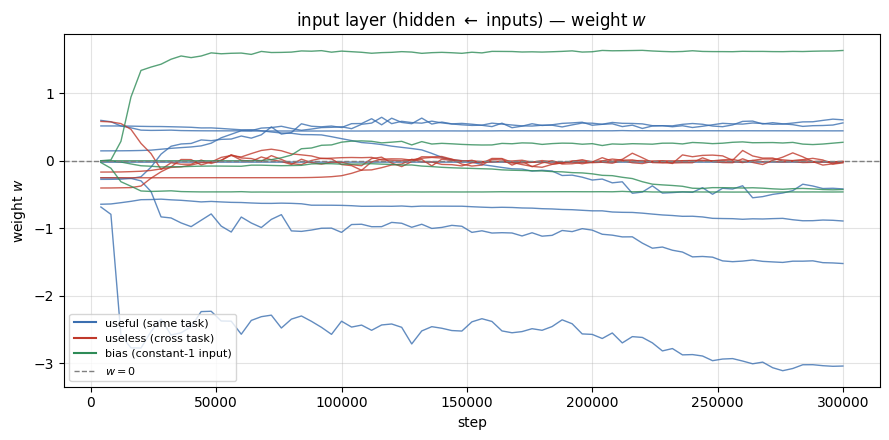

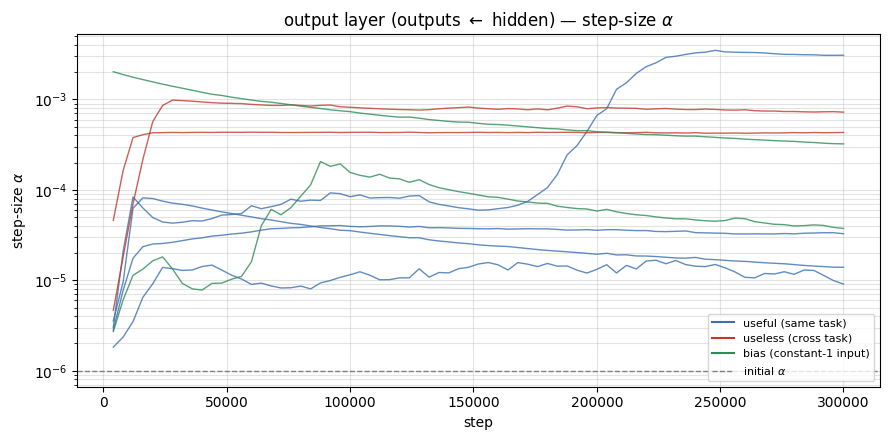

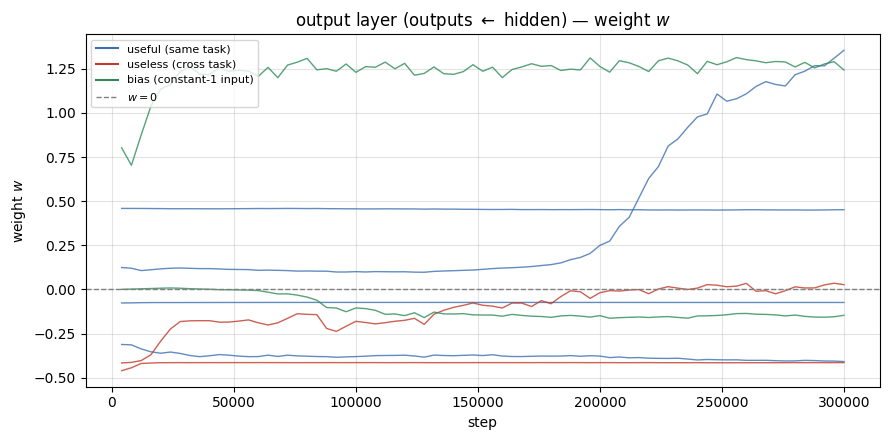

In [27]:
def plot_result(steps, alpha1, w1, alpha2, w2, title=''):
    """The four figures for one run: step-size and weight, input layer then output layer."""
    for layer_name, labels, alphas, ws in [
            ('input layer (hidden $\\leftarrow$ inputs)', labels1, alpha1, w1),
            ('output layer (outputs $\\leftarrow$ hidden)', labels2, alpha2, w2)]:
        for values, ylabel, log_scale in [(alphas, 'step-size $\\alpha$', True),
                                          (ws, 'weight $w$', False)]:
            plt.figure(figsize=(9, 4.5))
            for group, color, name in [(USEFUL, '#3b6fb0', 'useful (same task)'),
                                       (USELESS, '#c0392b', 'useless (cross task)'),
                                       (BIAS, '#2e8b57', 'bias (constant-1 input)')]:
                rows, cols = np.where(labels == group)
                for r, c in zip(rows, cols):
                    plt.plot(steps, values[:, r, c], color=color, lw=1.0, alpha=0.8)
                plt.plot([], [], color=color, lw=1.5, label=name)         # legend proxy
            if log_scale:
                plt.yscale('log')
                plt.axhline(INIT_ALPHA, ls='--', c='gray', lw=1, label='initial $\\alpha$')
            else:
                plt.axhline(0.0, ls='--', c='gray', lw=1, label='$w = 0$')
            plt.xlabel('step')
            plt.ylabel(ylabel)
            plt.title(f'{title}{layer_name} — {ylabel}')
            plt.grid(alpha=0.35, which='both')
            plt.legend(fontsize=8)
            plt.tight_layout()
            plt.show()


plot_result(snap_steps, snap_alpha1, snap_w1, snap_alpha2, snap_w2)

## Failure modes — useless connections that do not go to 0

1. **Dead unit.** If a unit dies and is always near 0, it gets no gradients, causing the weight to
   freeze where it is. (Seen above at `w2[1,0]`: hidden 0's pre-activation went permanently negative
   around step 20k, leaky-relu squashed it to a near-constant −0.005, and the weight has sat at
   −0.415 ever since. Its step-size froze too, at 4e-4.)

## Many runs at once

To hunt for more failure modes: `N_RUNS` independent teachers and networks, trained side by side.
Same maths as above — the very same `autostep` — with one extra leading axis for the run, so all of
them together cost about what one run costs. It also records, per hidden unit, the fraction of steps
it fired and the standard deviation of its activation, which is what makes a dead unit obvious.

In [28]:
N_RUNS = 12
SWEEP_SEED = 1


def run_many(n_runs=N_RUNS, n_steps=N_STEPS, seed=SWEEP_SEED):
    """Train `n_runs` independent networks, returning snapshots indexed [run, snapshot, ...]."""
    rng = np.random.default_rng(seed)

    # A teacher per run, built exactly like the single one above.
    t_in = rng.integers(0, 2, (n_runs, N_TASKS, TEACHER_HIDDEN, N_FEATURES_PER_TASK)).astype(float)
    t_out = (rng.integers(0, 2, (n_runs, N_TASKS, N_OUTPUTS_PER_TASK, TEACHER_HIDDEN)) * 2 - 1) \
        * (2.0 / np.sqrt(TEACHER_HIDDEN))

    def init(mask):                                     # LeCun uniform, zero bias, masked to zero
        bound = np.sqrt(3.0 / mask.shape[1])
        w = rng.uniform(-bound, bound, (n_runs,) + mask.shape)
        w[..., -1] = 0.0
        return w * mask

    w1, w2 = init(mask1), init(mask2)
    alpha1, alpha2 = np.full_like(w1, INIT_ALPHA), np.full_like(w2, INIT_ALPHA)
    h1, h2 = np.zeros_like(w1), np.zeros_like(w2)
    v1, v2 = np.zeros_like(w1), np.zeros_like(w2)
    ones = np.ones((n_runs, 1))

    snaps = {k: [] for k in ('alpha1', 'w1', 'alpha2', 'w2', 'hid_std', 'hid_frac_pos')}
    steps, hid_sum, hid_sq, n_pos = [], 0.0, 0.0, 0.0

    for step in range(1, n_steps + 1):
        x = rng.uniform(-1.0, 1.0, (n_runs, N_FEATURES))
        teacher_hid = np.einsum('rtmn,rtn->rtm', t_in,
                                x.reshape(n_runs, N_TASKS, N_FEATURES_PER_TASK)) > 0
        y = np.einsum('rtpm,rtm->rtp', t_out, teacher_hid.astype(float)).reshape(n_runs, N_OUTPUTS)
        y = y + NOISE_STD * rng.standard_normal((n_runs, N_OUTPUTS))

        # Forward, one network per run.
        xb = np.concatenate([x, ones], axis=1)
        pre = np.einsum('rij,rj->ri', w1 * mask1, xb)
        hid = np.where(pre > 0, pre, LEAKY_SLOPE * pre)
        hb = np.concatenate([hid, ones], axis=1)
        out = np.einsum('rij,rj->ri', w2 * mask2, hb)

        # Backward, the same expressions with a run axis in front.
        d_out = 2.0 * (out - y)
        g2 = d_out[:, :, None] * hb[:, None, :] * mask2
        d_hid = np.einsum('rij,ri->rj', w2 * mask2, d_out)[:, :N_HIDDEN]
        g1 = (d_hid * np.where(pre > 0, 1.0, LEAKY_SLOPE))[:, :, None] * xb[:, None, :] * mask1

        w1, alpha1, h1, v1 = autostep(w1, alpha1, h1, v1, g1, xb)
        w2, alpha2, h2, v2 = autostep(w2, alpha2, h2, v2, g2, hb)

        hid_sum, hid_sq, n_pos = hid_sum + hid, hid_sq + hid ** 2, n_pos + (pre > 0)
        if step % SNAPSHOT_EVERY == 0:
            steps.append(step)
            for key, value in (('alpha1', alpha1), ('w1', w1), ('alpha2', alpha2), ('w2', w2)):
                snaps[key].append(value.copy())
            mean = hid_sum / SNAPSHOT_EVERY             # activation stats over the block
            snaps['hid_std'].append(np.sqrt(np.maximum(0.0, hid_sq / SNAPSHOT_EVERY - mean ** 2)))
            snaps['hid_frac_pos'].append(n_pos / SNAPSHOT_EVERY)
            hid_sum, hid_sq, n_pos = 0.0, 0.0, 0.0

    sweep = {k: np.swapaxes(np.array(v), 0, 1) for k, v in snaps.items()}   # -> [run, snapshot, ...]
    sweep['steps'] = np.array(steps)
    return sweep


sweep = run_many()
print({k: v.shape for k, v in sweep.items()})

{'alpha1': (12, 75, 4, 5), 'w1': (12, 75, 4, 5), 'alpha2': (12, 75, 2, 5), 'w2': (12, 75, 2, 5), 'hid_std': (12, 75, 4), 'hid_frac_pos': (12, 75, 4), 'steps': (75,)}


### Where to look first

The worst surviving useless connection in each run, biggest first. `src fired` and `src std` describe
the unit the connection reads (the constant-1 bias for an input-layer connection, so they are only
meaningful for `w2`): `src fired ~ 0` with `src std ~ 0` is the dead-unit mode above. Anything near
the top of this table with a *live* source is a failure mode not yet on the list.

In [29]:
rows = []
for run in range(N_RUNS):
    for layer, labels in (('w1', labels1), ('w2', labels2)):
        w, alpha = sweep[layer][run, -1], sweep['alpha' + layer[-1]][run, -1]
        useless = np.argwhere(labels == USELESS)
        i, j = useless[np.argmax(np.abs(w[tuple(useless.T)]))]        # the largest one left
        src = (sweep['hid_frac_pos'][run, -1, j], sweep['hid_std'][run, -1, j]) \
            if layer == 'w2' and j < N_HIDDEN else (np.nan, np.nan)
        rows.append((run, layer, i, j, w[i, j], alpha[i, j], *src))

print(f"{'run':>4}{'layer':>7}{'i':>3}{'j':>3}{'w':>10}{'alpha':>11}{'src fired':>11}{'src std':>10}")
for run, layer, i, j, w, alpha, fired, std in sorted(rows, key=lambda r: -abs(r[4])):
    print(f'{run:>4}{layer:>7}{i:>3}{j:>3}{w:>10.3f}{alpha:>11.2e}{fired:>11.3f}{std:>10.4f}')

 run  layer  i  j         w      alpha  src fired   src std
   1     w1  3  1     0.226   1.09e-03        nan       nan
   4     w1  3  0    -0.211   9.02e-06        nan       nan
   8     w1  3  1     0.193   4.44e-04        nan       nan
   4     w2  1  0    -0.149   5.19e-05      0.751    0.4395
   8     w2  1  0    -0.145   1.43e-04      0.812    0.2861
   1     w2  1  0     0.115   2.58e-05      0.634    0.3852
   2     w1  1  3     0.081   7.15e-04        nan       nan
   7     w1  1  2    -0.058   9.52e-04        nan       nan
   9     w1  3  1     0.054   6.61e-04        nan       nan
   5     w1  3  0     0.054   1.42e-03        nan       nan
   0     w1  1  2    -0.051   5.31e-05        nan       nan
  11     w1  3  0    -0.042   6.34e-04        nan       nan
   2     w2  1  0    -0.038   1.17e-03      0.246    0.2483
   6     w1  3  0     0.038   2.30e-03        nan       nan
   5     w2  1  0     0.037   8.49e-04      0.436    0.1637
   6     w2  0  2    -0.035   1.40e-03  

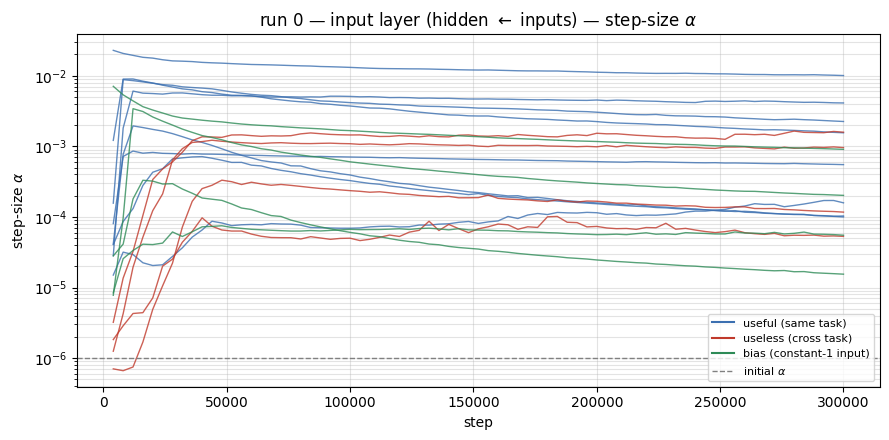

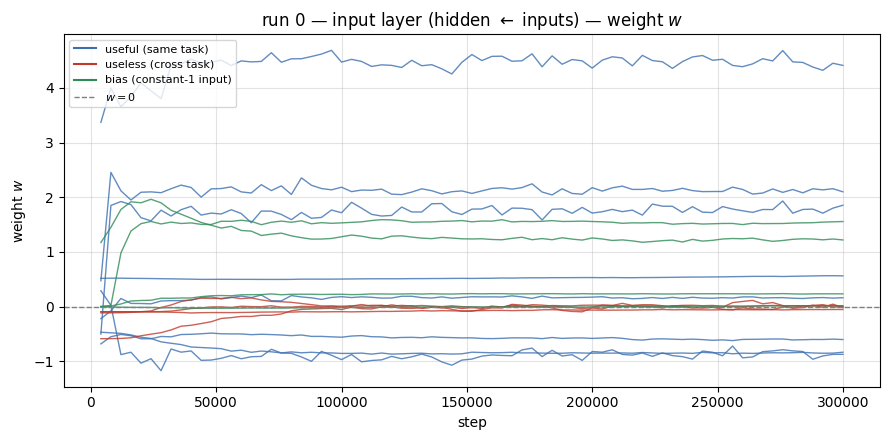

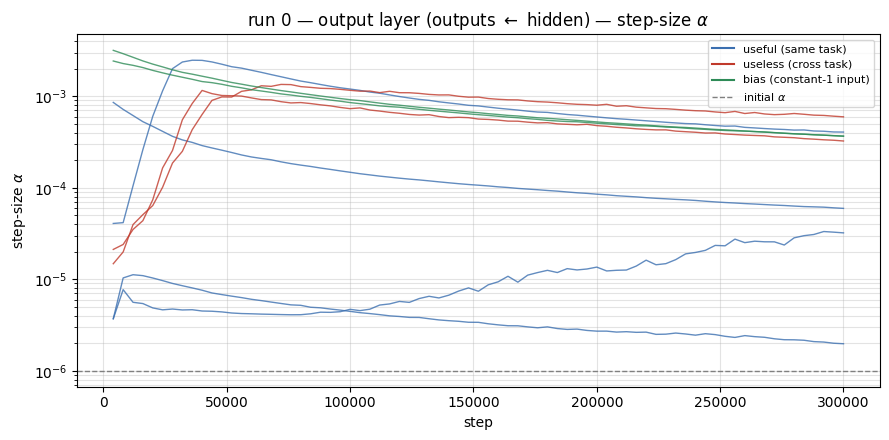

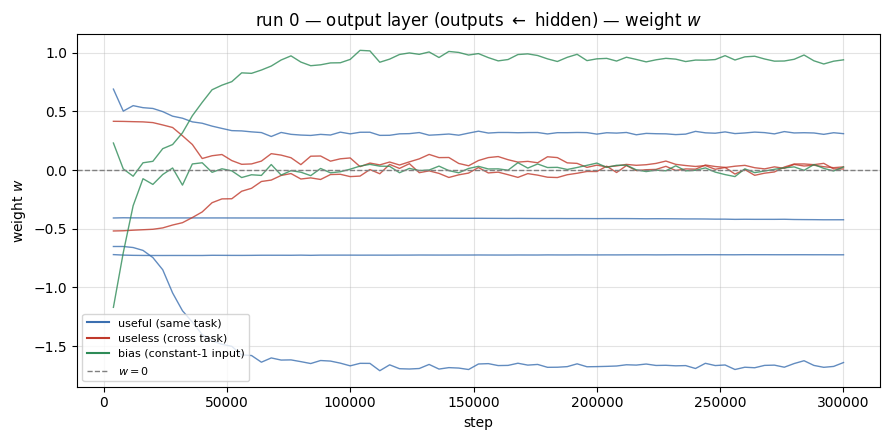

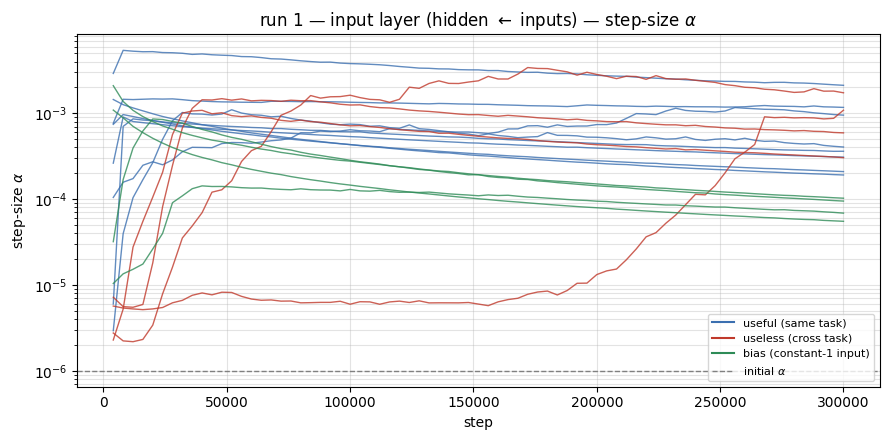

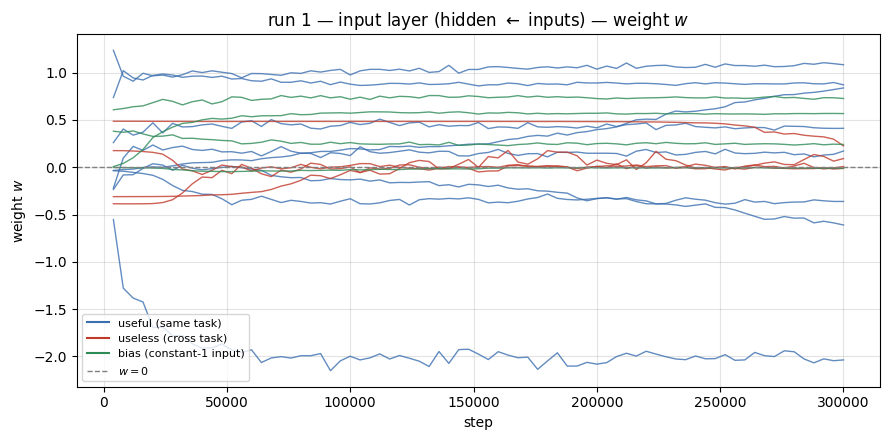

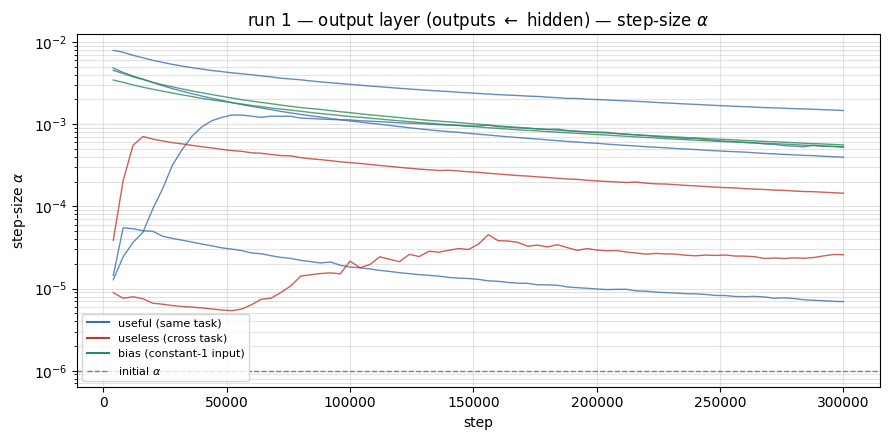

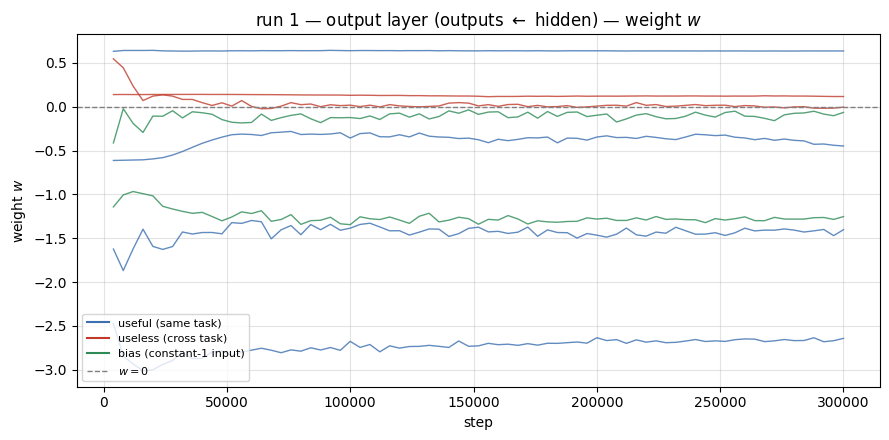

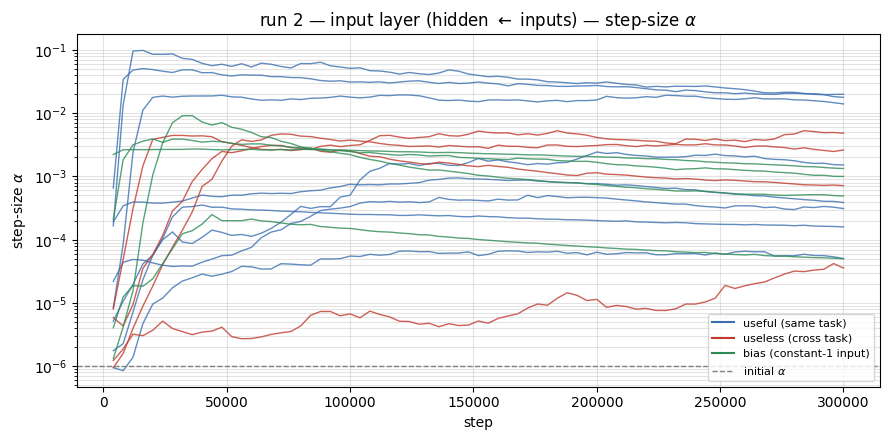

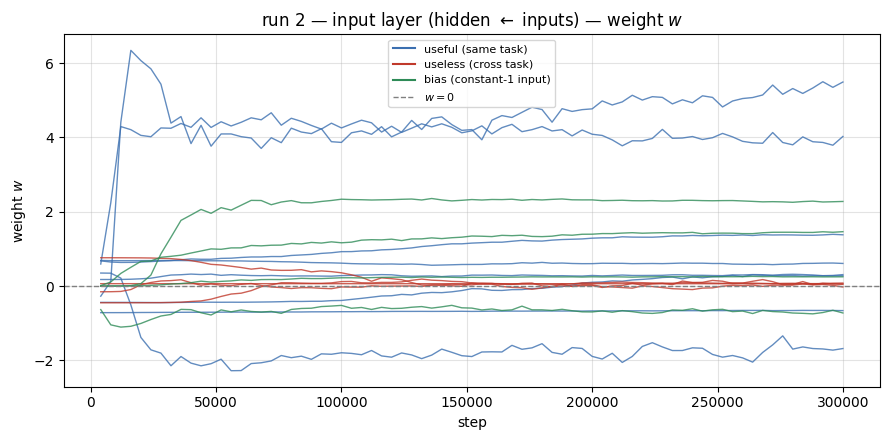

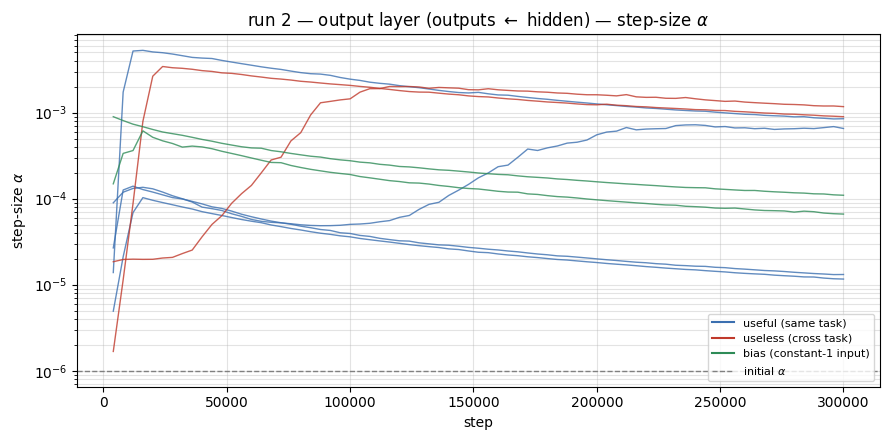

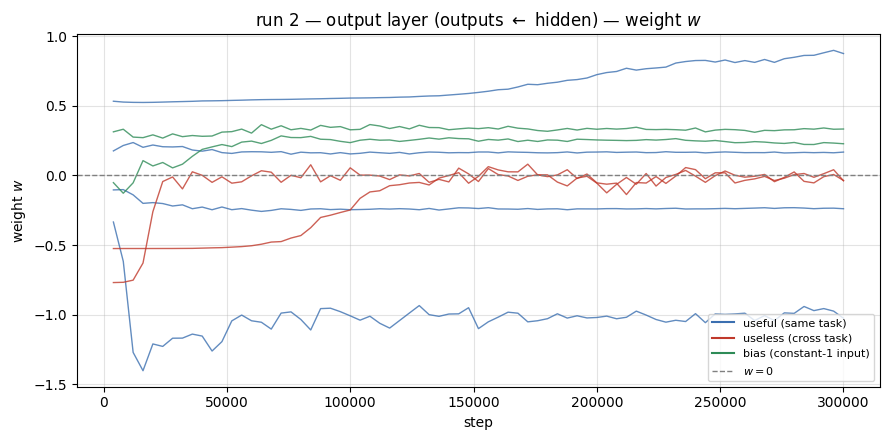

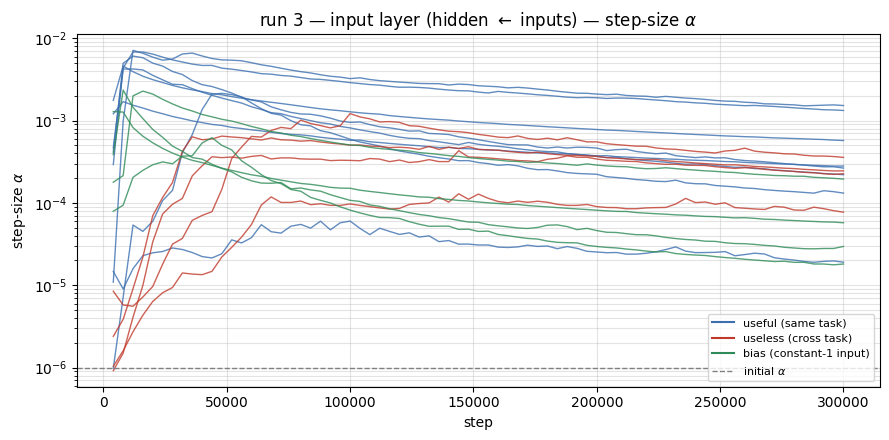

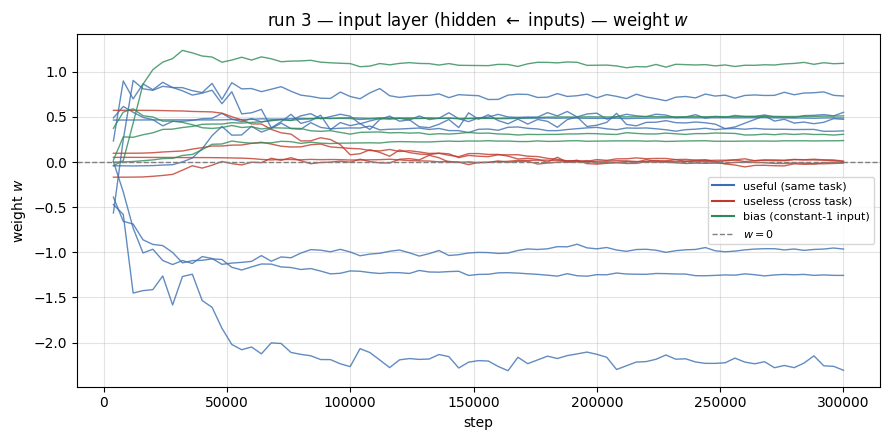

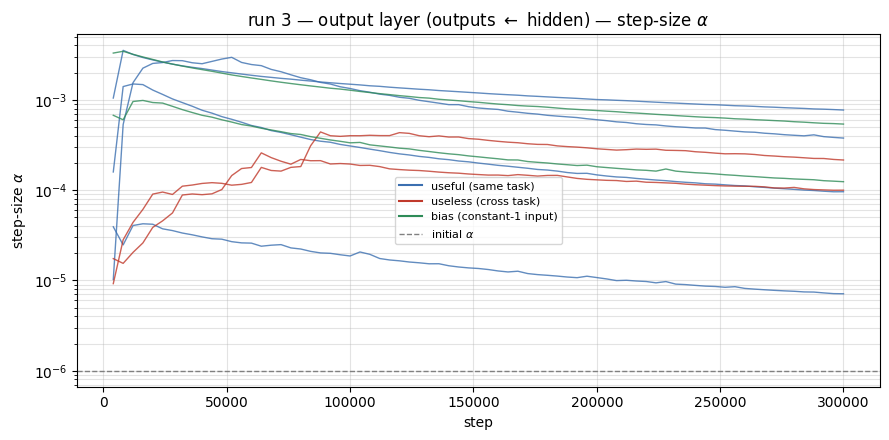

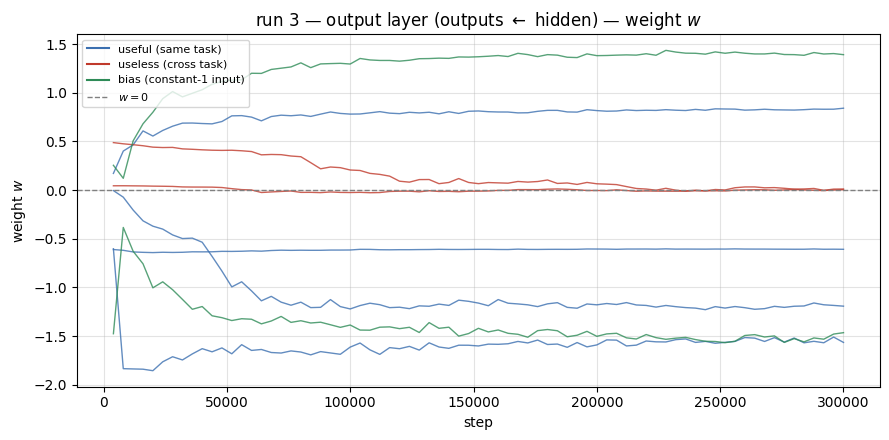

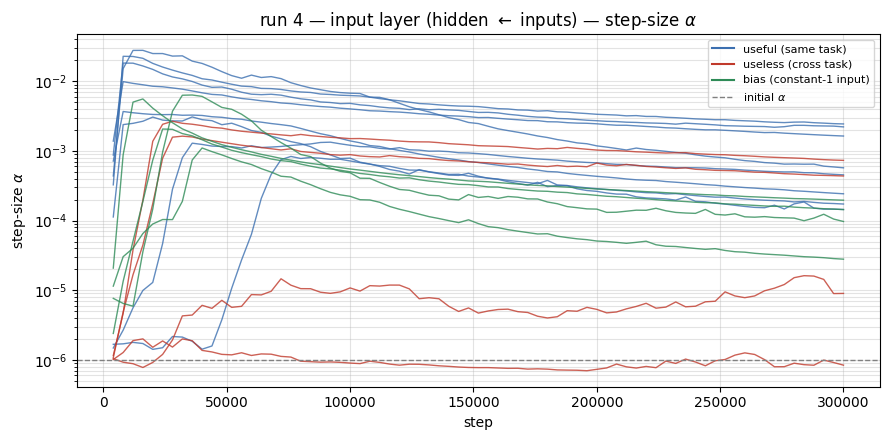

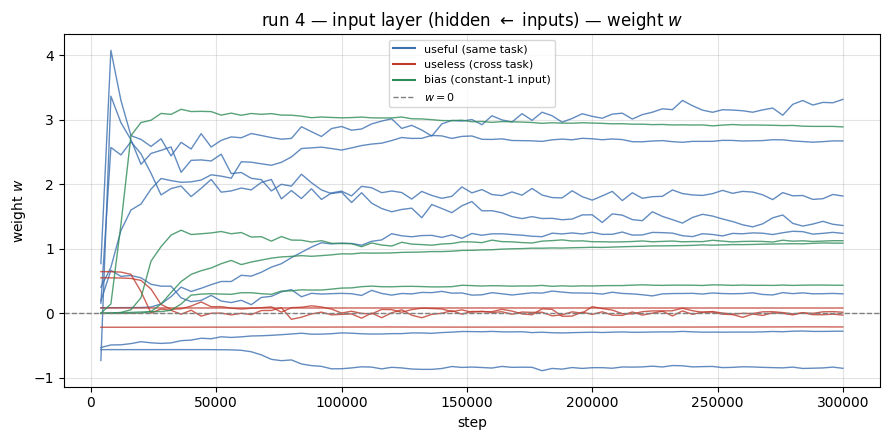

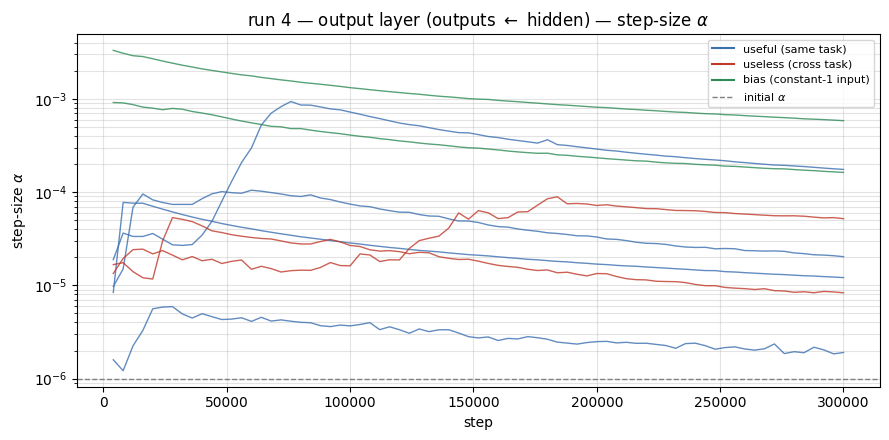

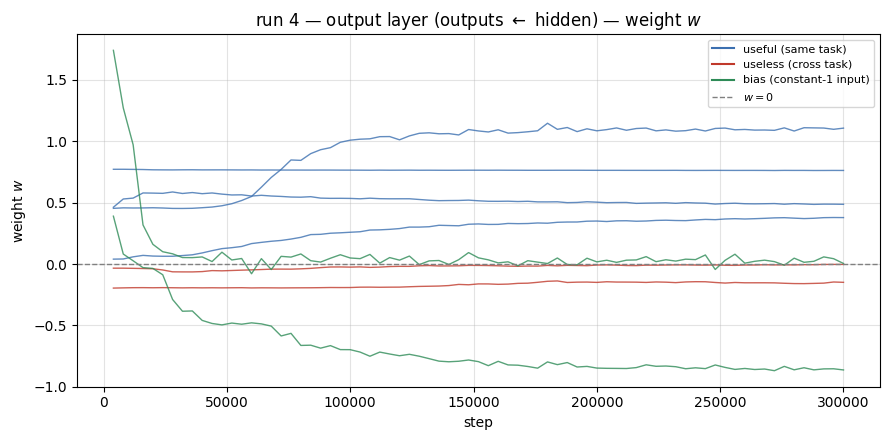

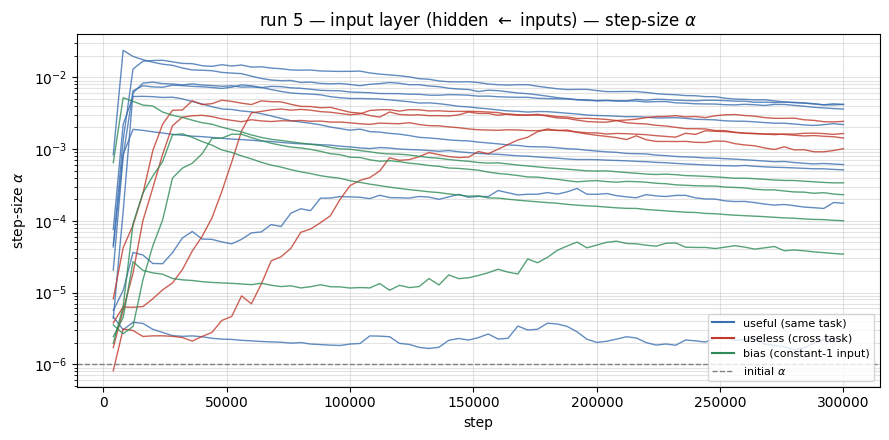

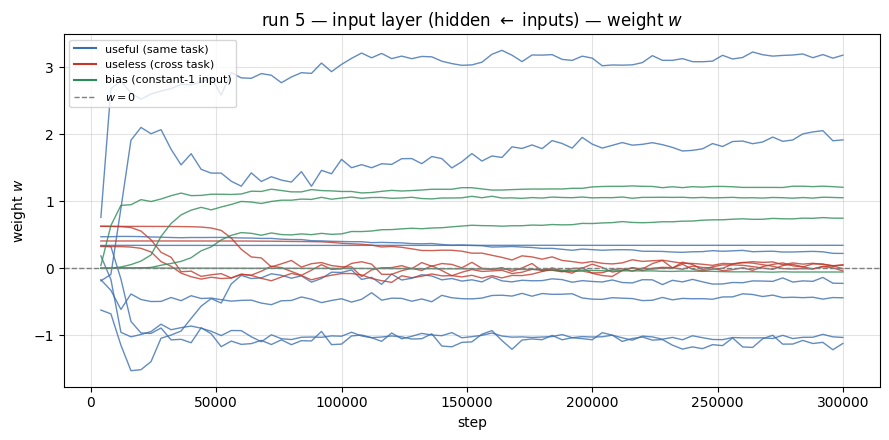

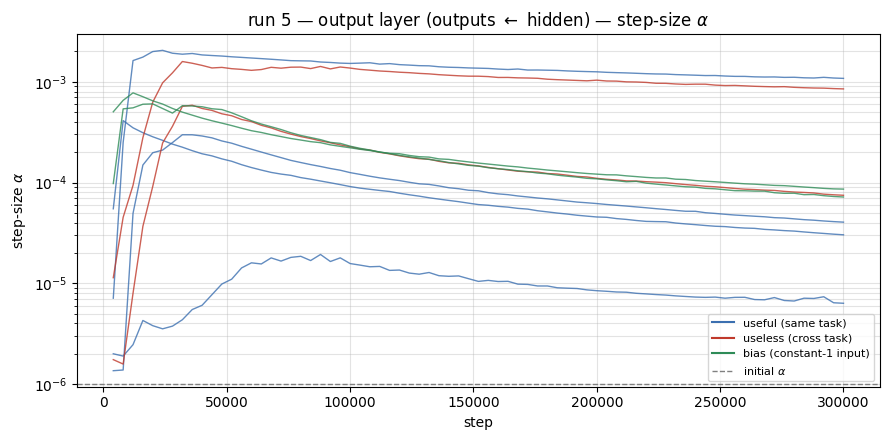

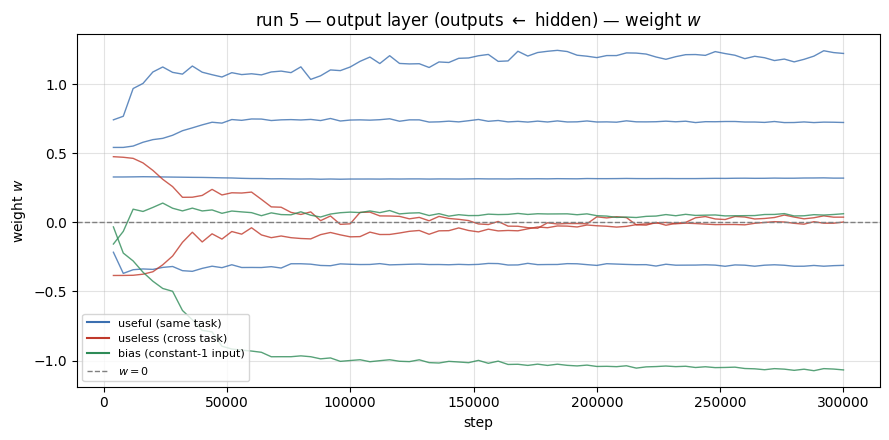

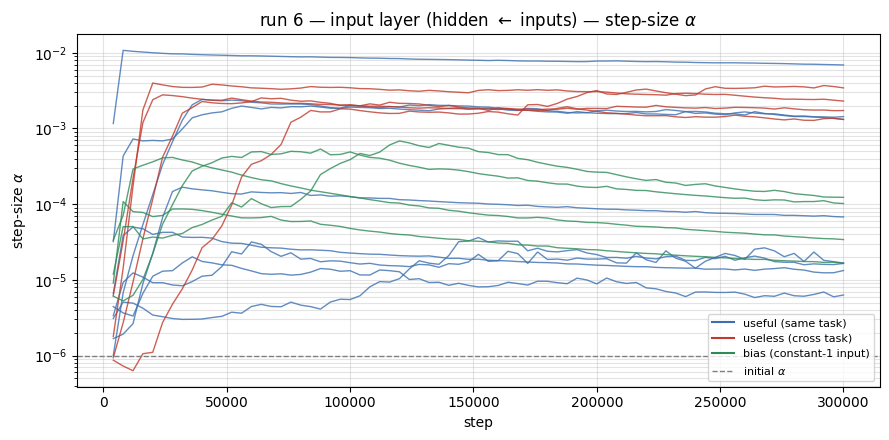

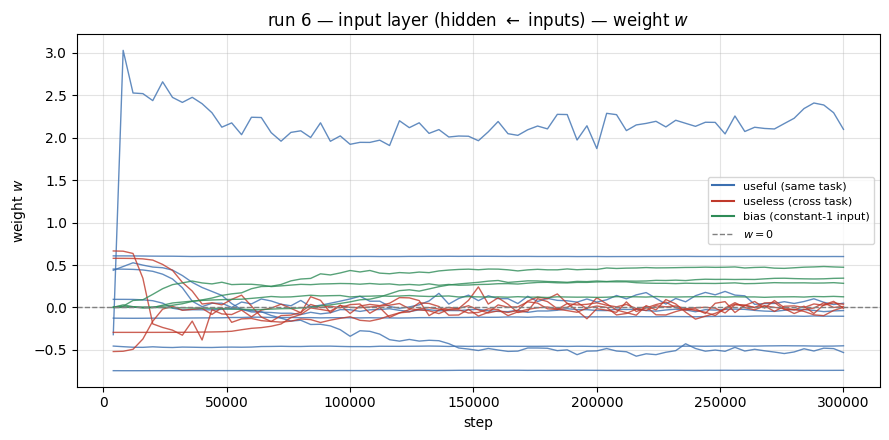

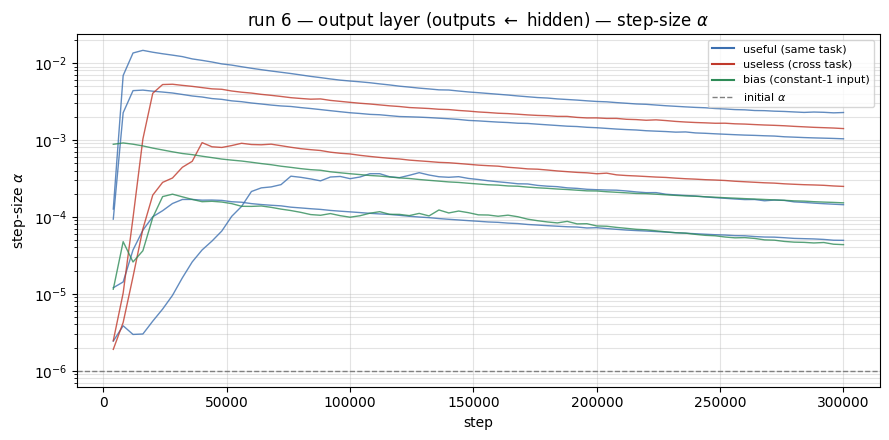

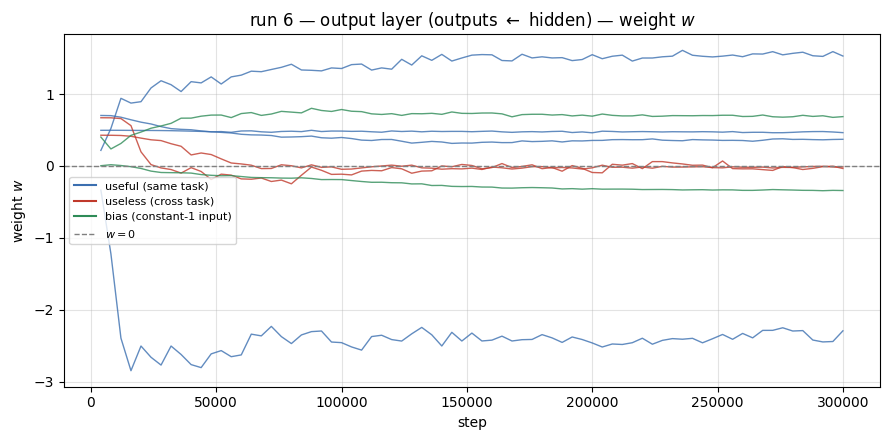

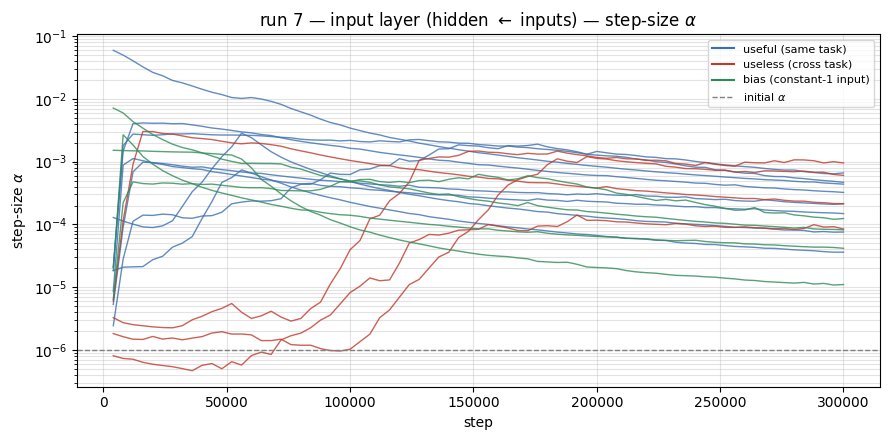

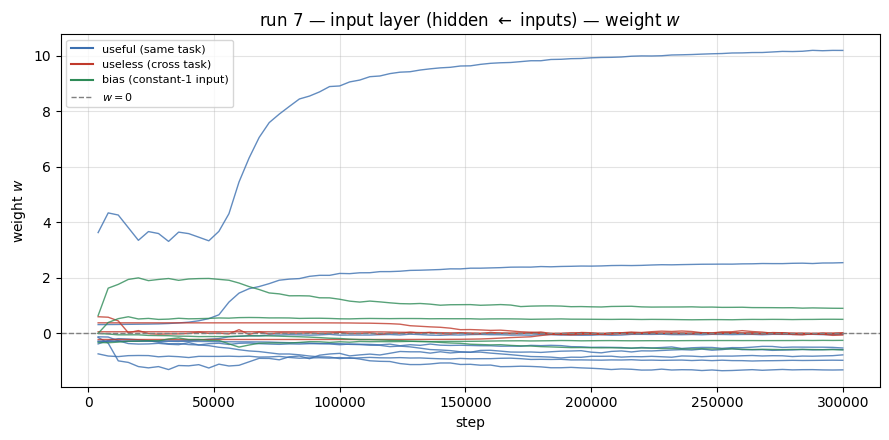

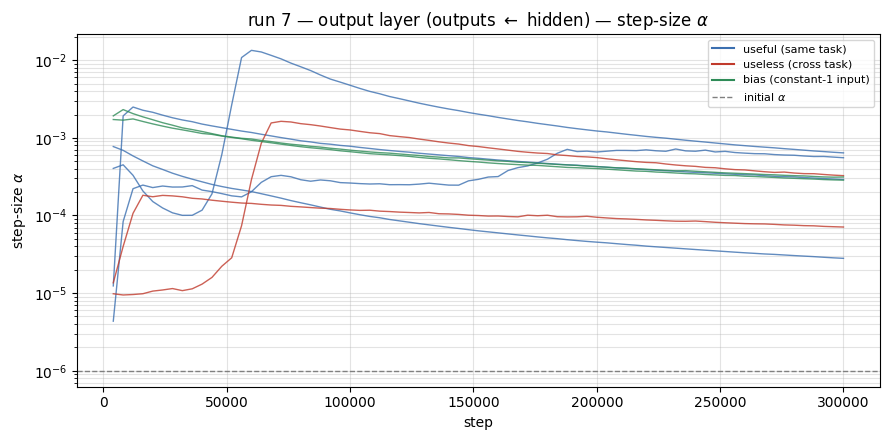

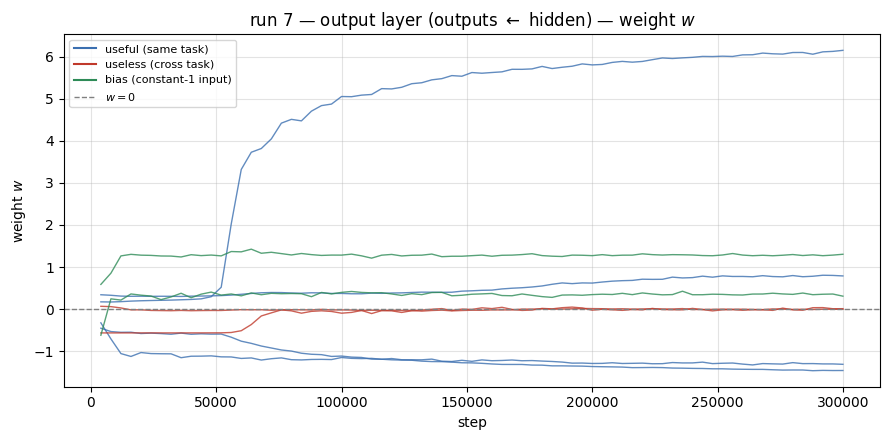

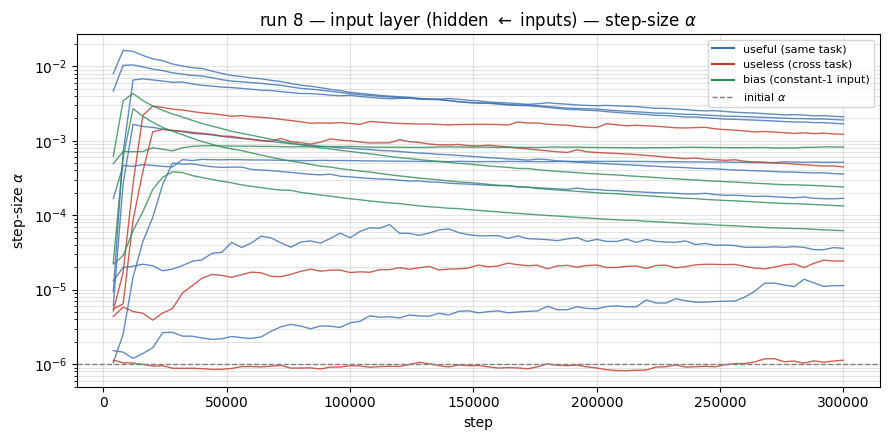

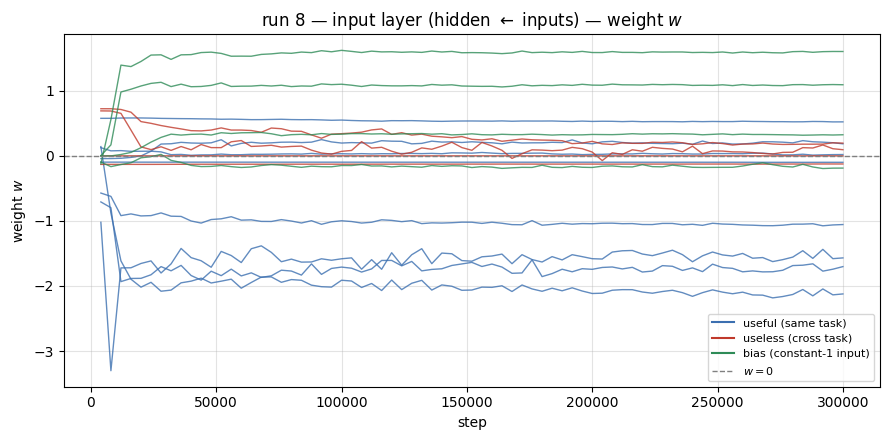

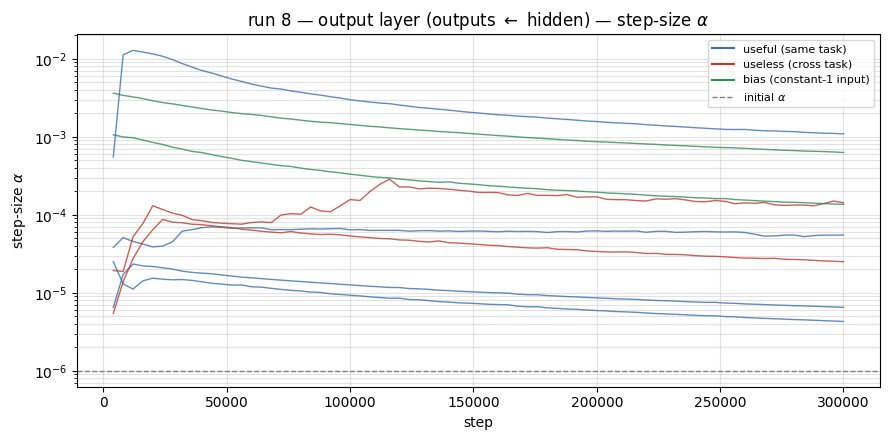

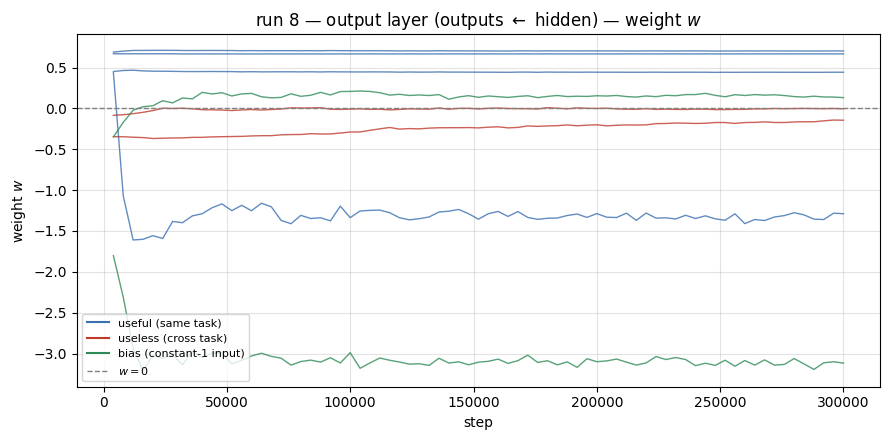

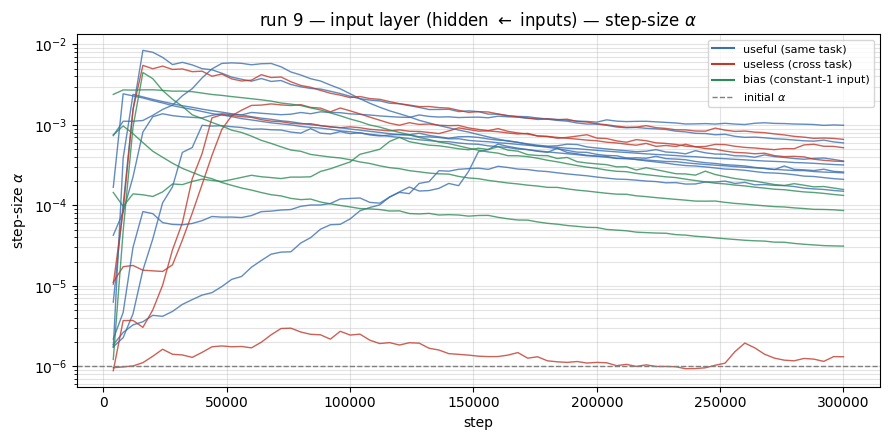

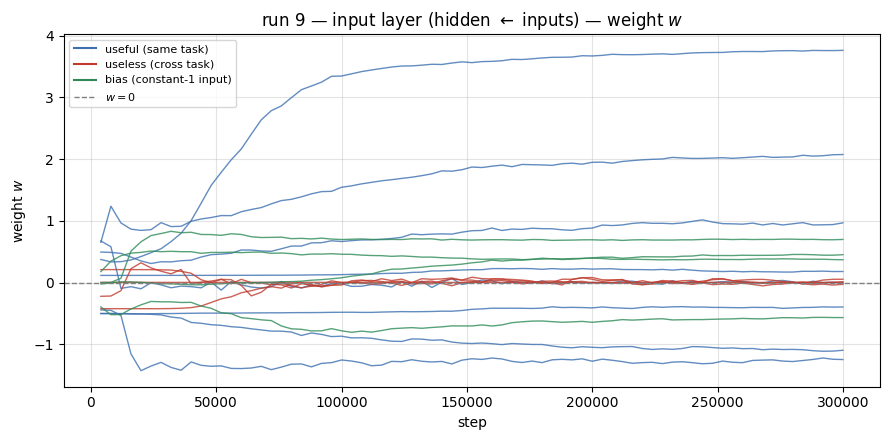

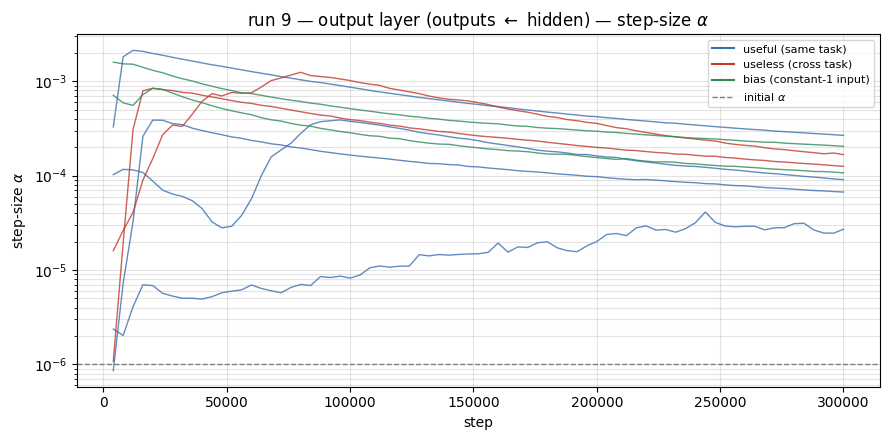

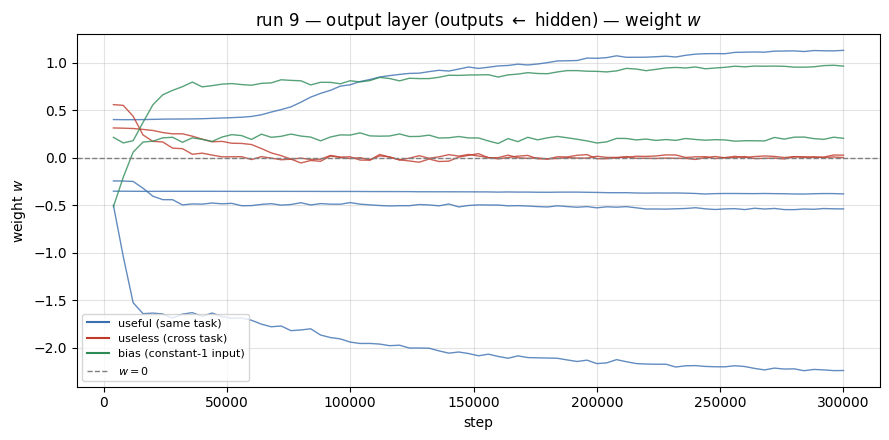

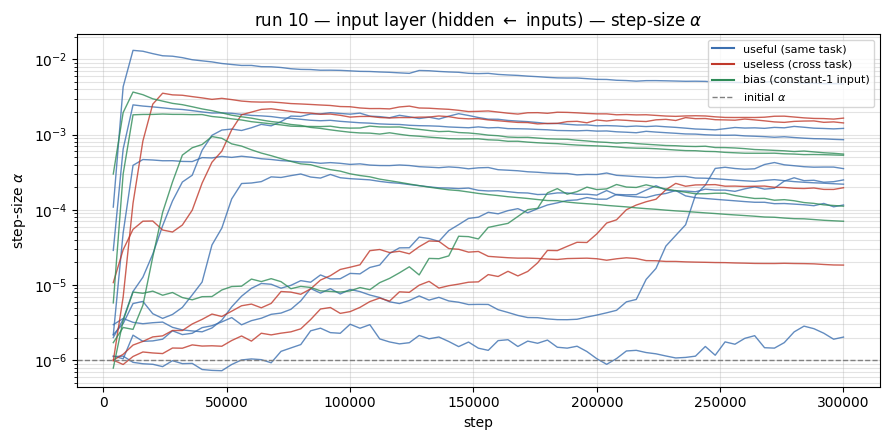

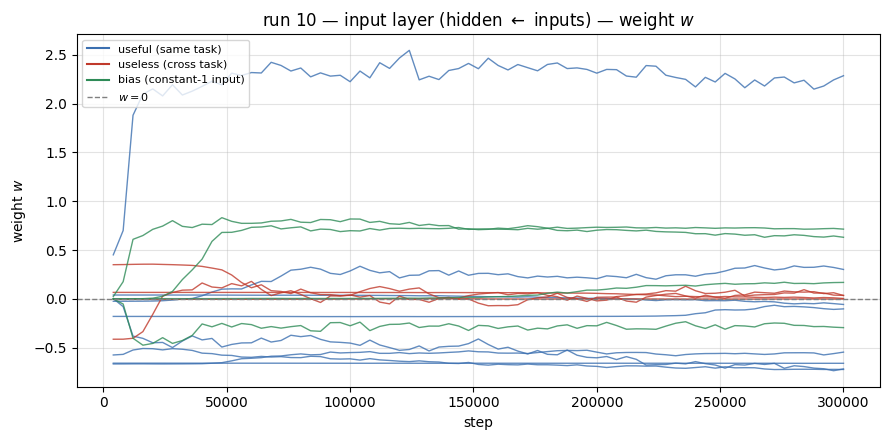

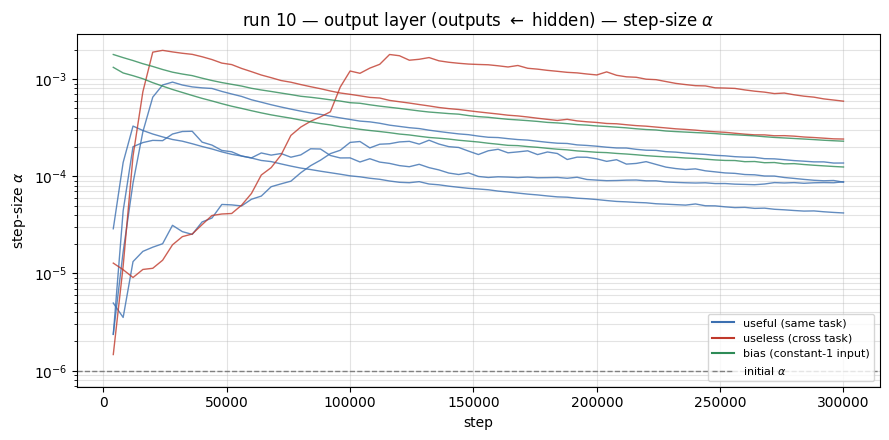

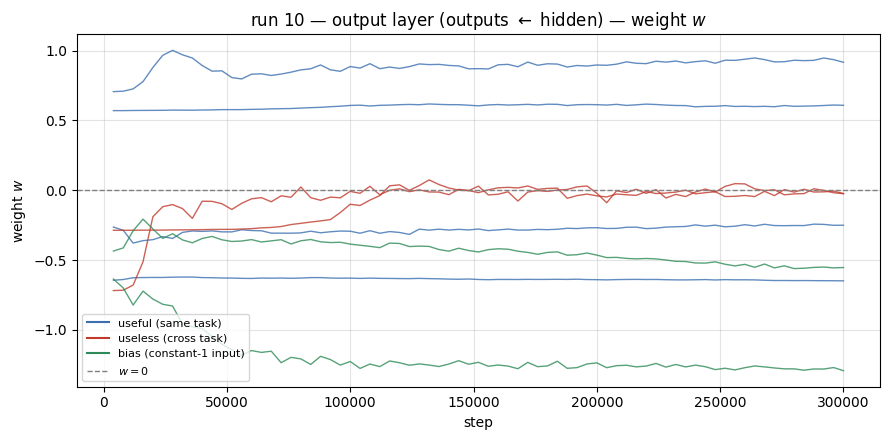

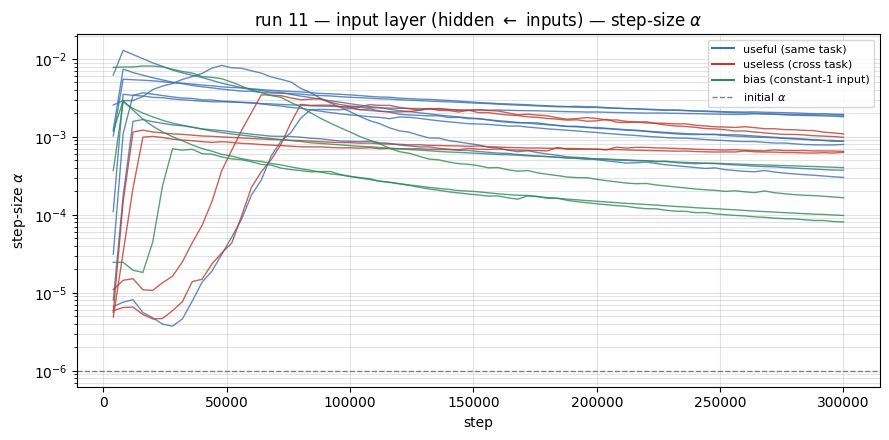

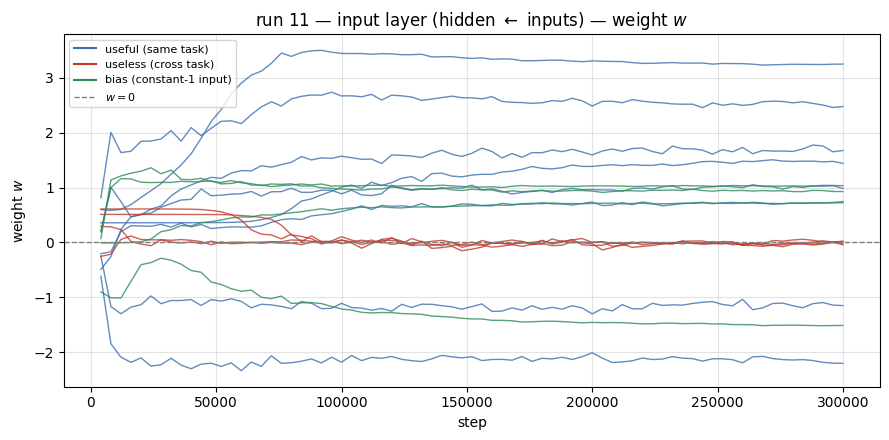

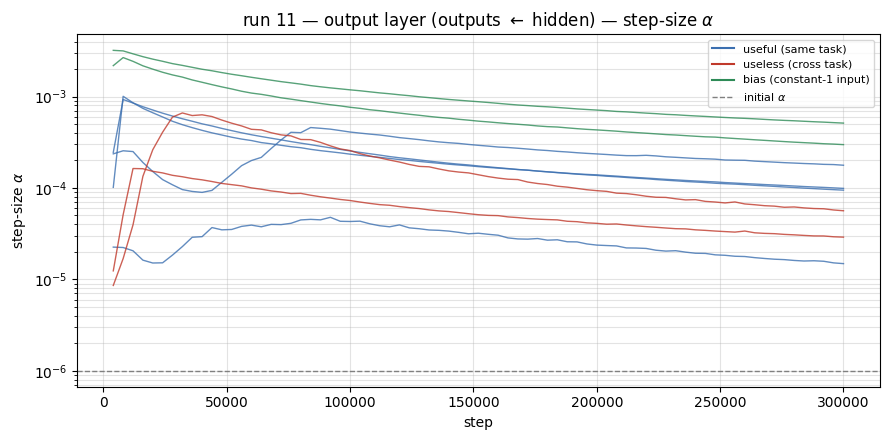

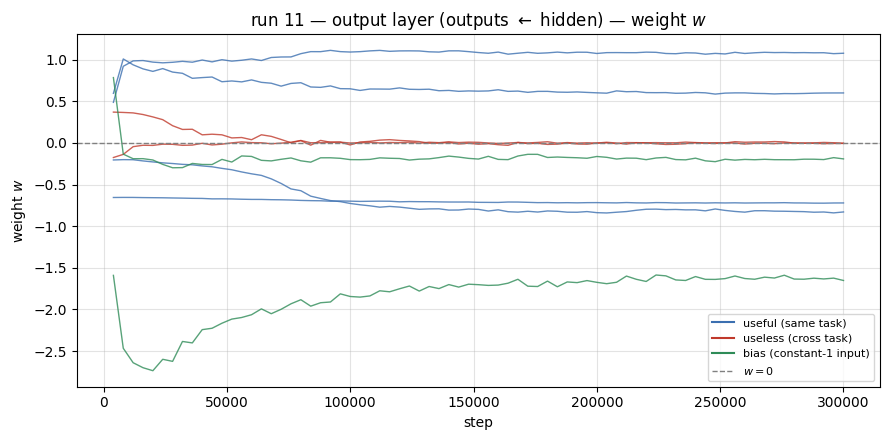

In [30]:
# Four figures per run. Narrow `RUNS_TO_PLOT` to the ones the table above flagged.
RUNS_TO_PLOT = range(N_RUNS)

for run in RUNS_TO_PLOT:
    plot_result(sweep['steps'], sweep['alpha1'][run], sweep['w1'][run],
                sweep['alpha2'][run], sweep['w2'][run], title=f'run {run} — ')